# Single-trial DFC → condition GCMI → exact permutations → group WfStats

This notebook walks through, step by step, a group analysis on **10 rodents**, two
experimental conditions (**PP** and **UP**, 4 trials each → 8 trials per rat):

1. **Dynamic Functional Connectivity (DFC)** between every pair of brain regions,
   single-trial, on sliding windows of `dt = 150` samples with `step = 1`.
2. **Mutual information (GCMI)** between the single-trial DFC and the discrete
   condition regressor `y` (0 = PP, 1 = UP), continuous–discrete flavour.
3. The **exact permutation null**: every distinct 4/4 relabelling of the 8 trials
   = C(8,4) = **70** permutations.
4. Pool true + permuted MI across rats and run the group statistics workflow
   **`WfStats`** (random-effects, cluster correction).

> **Interpretation note.** MI is estimated from only 8 trials, so per-window
> estimates are noisy and positively biased. The exact permutation test + RFX
> group statistics are what control for that — treat the per-rat MI as an effect
> size and read significance from `WfStats`.

## Setup

If you run this outside the repo environment, install the dependency:

```bash
pip install "frites" "numpy<2.0" xarray netcdf4
```

In [1]:
import numpy as np
import xarray as xr
from itertools import combinations

from frites.conn import conn_dfc
from frites.estimator import GCMIEstimator
from frites.workflow import WfStats

## Step 0 — Configuration

The 8 trials per rat are ordered `[PP, PP, PP, PP, UP, UP, UP, UP]` so they line
up with the regressor `Y = [0,0,0,0, 1,1,1,1]`.

In [2]:
RATS = [f"rat-{i:02d}" for i in range(1, 11)]   # 10 rodents
CONDITIONS = ["PP", "UP"]                        # PP -> y=0, UP -> y=1
N_TRIALS_PER_COND = 4                            # 4 trials / condition
DT = 150                                         # window length, in samples
STEP = 1                                         # window step, in samples

# regressor: 4 PP trials (0) then 4 UP trials (1)
Y = np.array([0] * N_TRIALS_PER_COND + [1] * N_TRIALS_PER_COND)
N_TRIALS = Y.size                                # 8

# continuous-discrete GCMI estimator (copula-normalised, bias-corrected)
ESTIMATOR = GCMIEstimator(mi_type="cd", copnorm=True, biascorrect=True,
                          verbose=False)

OUT_PREFIX = "dfc_mi_wfstats"                    # output file prefix
print(f"{len(RATS)} rats, {N_TRIALS} trials/rat, regressor Y = {Y}")

10 rats, 8 trials/rat, regressor Y = [0 0 0 0 1 1 1 1]


## Step 1 — Load one rat's data

**Replace `load_rat_data` with your real loader.** It must return `x` of shape
`(n_trials=8, n_roi, n_times)`, with trials ordered PP-then-UP, plus the region
names and the time vector. As shipped it simulates data so the notebook runs
end-to-end (an UP-only ROI0–ROI1 coupling is injected to create a real effect).

In [3]:
def load_rat_data(rat):
    """Return (x, roi, times) for one rat.

    x     : (n_trials=8, n_roi, n_times), trials ordered [PP*4, UP*4]
    roi   : list of region names, length n_roi
    times : time vector, length n_times
    """
    # ---- simulated stand-in so the notebook runs out of the box ----------
    rng = np.random.RandomState(abs(hash(rat)) % (2 ** 32))
    n_roi, n_times = 4, 600
    roi = [f"ROI{j}" for j in range(n_roi)]
    times = np.arange(n_times) / 1000.0          # e.g. 1 kHz sampling

    x = rng.randn(N_TRIALS, n_roi, n_times)
    sl = slice(200, 450)
    x[4:, 1, sl] += 0.8 * x[4:, 0, sl]           # UP trials only -> drives MI
    return x, roi, times
    # ----------------------------------------------------------------------


# quick look at one rat
x0, roi0, times0 = load_rat_data(RATS[0])
print("x:", x0.shape, "| roi:", roi0, "| n_times:", times0.size)

x: (8, 4, 600) | roi: ['ROI0', 'ROI1', 'ROI2', 'ROI3'] | n_times: 600


## Step 2 — Sliding windows

`conn_dfc` indexes the time vector with `[start, stop]` **inclusive**, so a
`DT`-sample window is `[start, start + DT - 1]` (using `start + DT` throws an
out-of-bounds error).

In [4]:
def build_windows(n_times):
    starts = np.arange(0, n_times - DT + 1, STEP)
    return np.c_[starts, starts + DT - 1]


win_sample = build_windows(times0.size)
print(f"{win_sample.shape[0]} windows of {DT} samples, step {STEP}")
print("first / last window:", win_sample[0], win_sample[-1])

451 windows of 150 samples, step 1
first / last window: [  0 149] [450 599]


## Step 3 — Single-trial DFC for one rat

`conn_dfc` returns an xarray with dims `(trials, roi, times)`, where `roi` holds
the region-**pair** names and `times` the window centres.

In [5]:
dfc = conn_dfc(x0, win_sample=win_sample, times=times0, roi=roi0,
               n_jobs=1, verbose=False)
print("DFC dims:", dfc.dims, "shape:", dfc.shape)
print("pairs:", [str(r) for r in dfc["roi"].values])
dfc

DFC dims: ('trials', 'roi', 'times') shape: (8, 6, 451)
pairs: ['ROI0-ROI1', 'ROI0-ROI2', 'ROI0-ROI3', 'ROI1-ROI2', 'ROI1-ROI3', 'ROI2-ROI3']


<xarray.DataArray 'DFC (Gaussian Copula Mutual Information Estimator)' (
                                                                        trials: 8,
                                                                        roi: 6,
                                                                        times: 451)> Size: 173kB
array([[[6.33416639e-04, 9.50156129e-04, 1.57438405e-03, ...,
         1.67775914e-04, 3.30544892e-04, 2.54922430e-04],
        [3.02027119e-03, 2.63212249e-03, 3.04255961e-03, ...,
         6.41806691e-04, 6.50158792e-04, 2.35037543e-04],
        [7.52785656e-09, 1.35093360e-05, 2.37645727e-04, ...,
         2.58929655e-03, 2.86793034e-03, 3.72348074e-03],
        [7.47757440e-04, 5.67190349e-04, 3.28491209e-04, ...,
         2.53178272e-02, 2.45071854e-02, 2.53521651e-02],
        [8.34300707e-04, 8.59762193e-04, 5.57381427e-04, ...,
         3.97964730e-04, 8.35673836e-06, 1.65129986e-05],
        [5.00682101e-04, 7.11321016e-04, 1.02812774e-03, ...,
         1.06851921e-05, 8.44447732e-06, 1.71611915e-04]],

       [[2.11913255e-03, 1.31167844e-03, 1.45035249e-03, ...,
         8.27497221e-04, 1.02166098e-03, 6.81414211e-04],
        [2.27670744e-03, 1.74727908e-03, 1.55255361e-03, ...,
         2.17785328e-07, 9.92892819e-06, 1.78181053e-05],
        [2.33616377e-03, 3.19780502e-03, 3.30409873e-03, ...,
         1.14107653e-02, 1.04091372e-02, 1.17233582e-02],
        [6.08182931e-03, 3.58191854e-03, 1.18984922e-03, ...,
...
         2.65918616e-02, 2.64163744e-02, 2.73620356e-02],
        [2.12720763e-02, 2.19056606e-02, 2.03444082e-02, ...,
         4.78333852e-04, 5.69446245e-04, 5.43469912e-04],
        [1.34110525e-02, 1.26561662e-02, 1.02832662e-02, ...,
         1.41263322e-03, 1.92849257e-03, 1.53275218e-03],
        [1.54032154e-04, 7.51401967e-05, 3.37714853e-04, ...,
         1.34922448e-04, 2.84627342e-04, 2.93850462e-04]],

       [[6.51352602e-05, 2.26989156e-04, 4.66438156e-04, ...,
         1.29573944e-03, 1.24040374e-03, 1.59736187e-03],
        [1.17901764e-04, 2.59705357e-05, 2.92498680e-06, ...,
         3.51220573e-04, 7.92988925e-04, 5.35515486e-04],
        [7.08641950e-03, 7.56075140e-03, 7.92569760e-03, ...,
         3.33613157e-02, 2.96511948e-02, 3.15134488e-02],
        [7.10441638e-03, 3.96346580e-03, 5.45190228e-03, ...,
         4.66580736e-03, 6.29914599e-03, 7.90762249e-03],
        [5.65474201e-03, 5.71916718e-03, 5.61527675e-03, ...,
         2.38787066e-02, 2.47301124e-02, 2.43558921e-02],
        [3.74180404e-03, 2.44794553e-03, 2.69347429e-03, ...,
         5.36913378e-03, 7.82694947e-03, 7.07509369e-03]]])
Coordinates:
  * trials   (trials) int64 64B 0 1 2 3 4 5 6 7
  * roi      (roi) <U9 216B 'ROI0-ROI1' 'ROI0-ROI2' ... 'ROI1-ROI3' 'ROI2-ROI3'
  * times    (times) float64 4kB 0.0745 0.0755 0.0765 ... 0.5225 0.5235 0.5245
Attributes:
    win_sample:  [  0 149   1 150   2 151   3 152   4 153   5 154   6 155   7...
    win_times:   [0.0745 0.0755 0.0765 0.0775 0.0785 0.0795 0.0805 0.0815 0.0...
    agg_ch:      0
    type:        dfc
    estimator:   Gaussian Copula Mutual Information Estimator
    unit:        Bits
    sfreq:       1000.0
    sources:     [0, 0, 0, 1, 1, 2]
    targets:     [1, 2, 3, 2, 3, 3]

## Step 4 — MI between DFC and the condition regressor

GCMI (continuous–discrete) between each pair × window DFC time series (across
the 8 trials) and the discrete labels. The estimator wants `x` shaped
`(n_var, n_mv, n_samples)`; here `n_var = pairs × windows`, `n_mv = 1`,
`n_samples = trials`.

In [6]:
def dfc_to_mi(dfc_vals, labels):
    """GCMI(cd) -> (n_pairs, n_win) from DFC (n_trials, n_pairs, n_win)."""
    n_trials, n_pairs, n_win = dfc_vals.shape
    x = dfc_vals.transpose(1, 2, 0).reshape(n_pairs * n_win, 1, n_trials)
    mi = ESTIMATOR.estimate(x, labels.astype(float))   # (1, n_pairs*n_win)
    return mi.reshape(n_pairs, n_win)


mi0 = dfc_to_mi(dfc.values, Y)
print("true MI shape (pairs, windows):", mi0.shape)

true MI shape (pairs, windows): (6, 451)


## Step 5 — The exact permutation set

Every distinct relabelling of the 8 trials into a 4/4 split. Because labels are
exchangeable within a condition, this is C(8,4) = **70** (not 8!).

In [7]:
def exact_permutations():
    perms = []
    for ones in combinations(range(N_TRIALS), N_TRIALS_PER_COND):
        lab = np.zeros(N_TRIALS, dtype=int)
        lab[list(ones)] = 1
        perms.append(lab)
    return np.asarray(perms)


perms_labels = exact_permutations()
n_perm = perms_labels.shape[0]
print(f"{n_perm} permutations, e.g. {perms_labels[0]} ... {perms_labels[-1]}")

70 permutations, e.g. [1 1 1 1 0 0 0 0] ... [0 0 0 0 1 1 1 1]


## Step 6 — Loop over rats: accumulate effect + permutations

For every rat: DFC → true MI → 70 permuted MIs. We collect per-rat arrays and
capture the pair names / window times once.

In [8]:
effect_per_rat = []      # each: (n_pairs, n_win)
perms_per_rat = []       # each: (n_perm, n_pairs, n_win)
pair_names = win_times = None

for rat in RATS:
    x, roi, times = load_rat_data(rat)
    assert x.shape[0] == N_TRIALS, f"{rat}: expected {N_TRIALS} trials"

    ws = build_windows(x.shape[-1])
    dfc = conn_dfc(x, win_sample=ws, times=times, roi=roi,
                   n_jobs=1, verbose=False)
    dfc_vals = dfc.values                                  # (8, n_pairs, n_win)

    effect = dfc_to_mi(dfc_vals, Y)                        # (n_pairs, n_win)
    perms = np.stack([dfc_to_mi(dfc_vals, perms_labels[p])
                      for p in range(n_perm)], axis=0)     # (70, n_pairs, n_win)

    effect_per_rat.append(effect)
    perms_per_rat.append(perms)

    if pair_names is None:
        pair_names = [str(r) for r in dfc["roi"].values]
        win_times = dfc["times"].values
    print(f"  {rat}: DFC {dfc_vals.shape} -> MI {effect.shape}")

  rat-01: DFC (8, 6, 451) -> MI (6, 451)


  rat-02: DFC (8, 6, 451) -> MI (6, 451)


  rat-03: DFC (8, 6, 451) -> MI (6, 451)


  rat-04: DFC (8, 6, 451) -> MI (6, 451)


  rat-05: DFC (8, 6, 451) -> MI (6, 451)


  rat-06: DFC (8, 6, 451) -> MI (6, 451)


  rat-07: DFC (8, 6, 451) -> MI (6, 451)


  rat-08: DFC (8, 6, 451) -> MI (6, 451)


  rat-09: DFC (8, 6, 451) -> MI (6, 451)


  rat-10: DFC (8, 6, 451) -> MI (6, 451)


## Step 7 — Pool across rats and shape inputs for `WfStats`

`WfStats.fit` wants a **list with one entry per pair**:
`effect[pair]` of shape `(n_subjects, n_times)` and
`perms[pair]` of shape `(n_perm, n_subjects, n_times)`.

In [9]:
eff = np.stack(effect_per_rat, axis=1)        # (n_pairs, n_subjects, n_win)
prm = np.stack(perms_per_rat, axis=2)         # (n_perm, n_pairs, n_subjects, n_win)
n_pairs = eff.shape[0]
print("pooled effect:", eff.shape, "| pooled perms:", prm.shape)

effect_list = [eff[p] for p in range(n_pairs)]
perms_list = [prm[:, p] for p in range(n_pairs)]

pooled effect: (6, 10, 451) | pooled perms: (70, 6, 10, 451)


## Step 8 — Group statistics with `WfStats`

Random-effects inference with cluster-based multiple-comparison correction.
Returns `(n_windows, n_pairs)` p- and t-values.

In [10]:
wf = WfStats(verbose=False)
pvalues, tvalues = wf.fit(effect_list, perms_list, inference="rfx",
                          mcp="cluster", tail=1)
pvalues, tvalues = np.asarray(pvalues), np.asarray(tvalues)
print("pvalues:", pvalues.shape, "| tvalues:", tvalues.shape)
print("significant (p<0.05) pair x window points:", int((pvalues < 0.05).sum()))

pvalues: (451, 6) | tvalues: (451, 6)
significant (p<0.05) pair x window points: 367


## Step 9 — Save labelled results

In [11]:
coords = {"times": win_times, "roi": pair_names}
dims = ("times", "roi")

xr.DataArray(eff.mean(1).T, coords=coords, dims=dims,
             name="mi").to_netcdf(f"{OUT_PREFIX}_mi_mean.nc")
xr.DataArray(pvalues, coords=coords, dims=dims,
             name="pvalues").to_netcdf(f"{OUT_PREFIX}_pvalues.nc")
xr.DataArray(tvalues, coords=coords, dims=dims,
             name="tvalues").to_netcdf(f"{OUT_PREFIX}_tvalues.nc")
print(f"Saved {OUT_PREFIX}_{{mi_mean,pvalues,tvalues}}.nc")

Saved dfc_mi_wfstats_{mi_mean,pvalues,tvalues}.nc


## Step 10 — Quick visualisation (optional)

Mean MI across rats and the significance mask for each region pair.

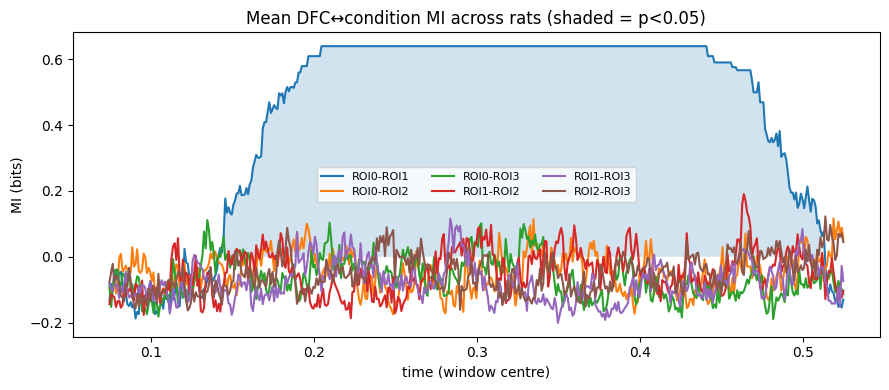

In [12]:
import matplotlib.pyplot as plt

mi_mean = eff.mean(1)                     # (n_pairs, n_win)
fig, ax = plt.subplots(figsize=(9, 4))
for p, name in enumerate(pair_names):
    ax.plot(win_times, mi_mean[p], label=name)
    sig = pvalues[:, p] < 0.05
    ax.fill_between(win_times, 0, mi_mean[p], where=sig, alpha=0.2)
ax.set(xlabel="time (window centre)", ylabel="MI (bits)",
       title="Mean DFC↔condition MI across rats (shaded = p<0.05)")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()